<a href="https://colab.research.google.com/github/ajose3-ui/individuation-training/blob/main/final_project/FinalProject_Analysis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Click to copy the class code repository
!git clone https://github.com/mattsmiths/biol470.git

Cloning into 'biol470'...
remote: Enumerating objects: 914, done.
remote: Counting objects: 100% (319/319), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 914 (delta 224), reused 229 (delta 162), pack-reused 595 (from 3)
Receiving objects: 100% (914/914), 934.07 MiB | 20.46 MiB/s, done.
Resolving deltas: 100% (382/382), done.
Updating files: 100% (356/356), done.


In [2]:
#@title Click to import libraries
import cv2 as cv
import os
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd

In [3]:
data1 = pd.read_csv('/content/biol470/final_project/nicotine_bee_1/assay4_inf_final_bee_0415_exp_01_air_cam1_2026-04-15_18-02-38_key.csv')

# New Section

In [ ]:
data1.head()

,Unnamed: 0,filepath,x_centroid,y_centroid,x_min,y_min,x_max,y_max,detection_confidence
0,0,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2866.5,2485.0,2499,2134,3234,2836,0.787689
1,1,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2863.5,2488.0,2513,2139,3214,2837,0.778611
2,2,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2863.5,2490.5,2511,2133,3216,2848,0.752090
3,3,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2824.0,2491.5,2478,2131,3170,2852,0.737394
4,4,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2813.5,2491.0,2458,2131,3169,2851,0.725658


In [ ]:
x_store = []
y_store = []

# Pulling out the centroid for each detection event
for ind,ele in enumerate(data1['x_min']):
  x_center = (ele+data1['x_max'][ind])/2
  y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
  x_store.append(x_center)
  y_store.append(y_center)





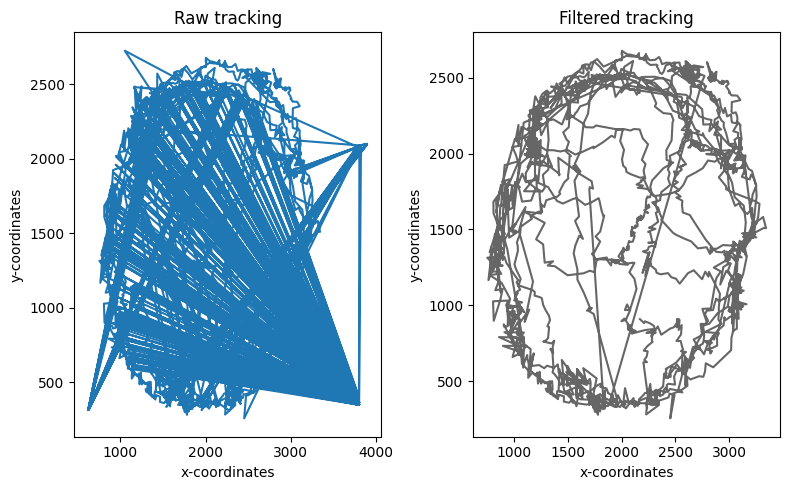

In [ ]:
# Plotting the centroid in x-y space over time
# raw plot
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.title('Raw tracking')
plt.plot(x_store,y_store)
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')

speed = []
x_plot = []
y_plot = []
# updating to euclidean distance
for ind,x1 in enumerate(x_store[1:]):
  previous_pos = np.array([x_store[ind],y_store[ind]])
  current_pos = np.array([x_store[ind+1],y_store[ind+1]])

  # Euclidean distance calculation
  temp = np.linalg.norm((current_pos-previous_pos))

  speed.append(temp)

  # removing noise
  if temp < 250 and x_store[ind+1] < 3500:
    x_plot.append(x_store[ind+1])
    y_plot.append(y_store[ind+1])


plt.subplot(1,2,2)
plt.title('Filtered tracking')
plt.plot(x_plot,y_plot,color=(0.4,0.4,0.4))
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
plt.tight_layout()


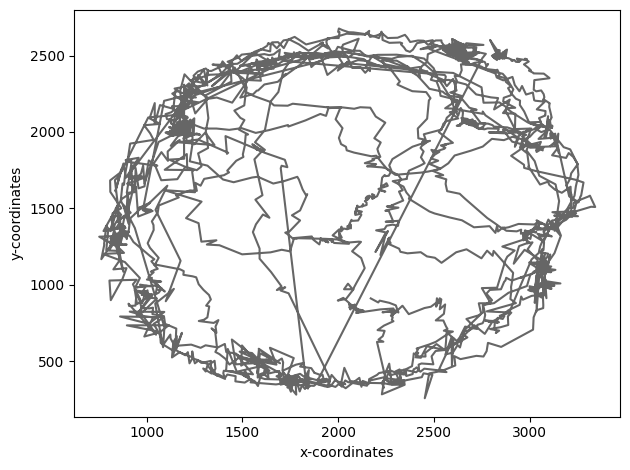

In [ ]:

#plt.title('Filtered tracking')
plt.plot(x_plot,y_plot,color=(0.4,0.4,0.4))
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
plt.tight_layout()
plt.savefig('/content/circle.jpg',dpi=200)

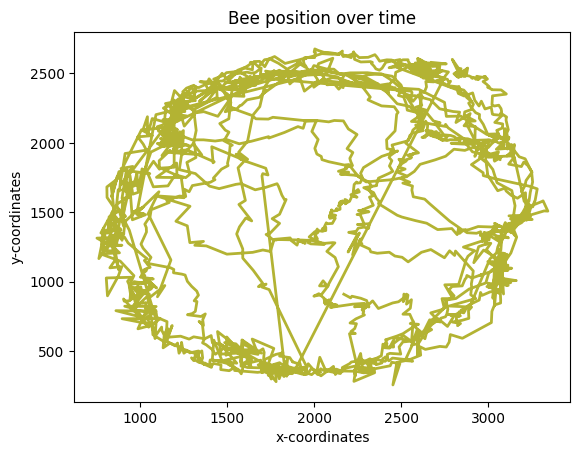

In [ ]:
# Plotting the centroid in x-y space over time
plt.plot(x_plot,y_plot,color=(0.7,0.7,0.2),linewidth=2)
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
plt.title('Bee position over time')
plt.savefig('control_bee2_assay_1.pdf',dpi=200)

In [ ]:
#xdiff = np.diff(x_store)
#ydiff = np.diff(y_store)
#out = abs(xdiff)+abs(ydiff)

speed = []
# updating to euclidean distance
for ind,x1 in enumerate(x_store[1:]):
  previous_pos = np.array([x_store[ind],y_store[ind]])
  current_pos = np.array([x_store[ind+1],y_store[ind+1]])

  # Euclidean distance calculation
  temp = np.linalg.norm((current_pos-previous_pos))

  speed.append(temp)

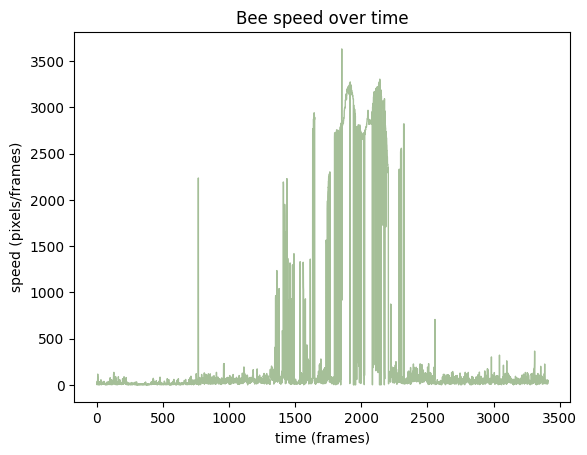

In [ ]:
# Plotting the centroid in x-y space over time
plt.plot(speed,color=(0.3,0.5,0.2,0.5),linewidth=1)
plt.xlabel('time (frames)')
plt.ylabel('speed (pixels/frames)')
plt.title('Bee speed over time')
plt.savefig('control_bee2_assay_1_speed.pdf',dpi=200)

In [ ]:
assayList = ['/content/biol470/final_project/control_bee_2/assay1_inf_bee_0408_2_opto_2026-04-08_16-35-41_arena_circle_1_key.csv',
             '/content/biol470/final_project/control_bee_3/assay1_inf_bee_0408_3_opto_2026-04-08_17-28-06_arena_circle_1_key.csv',
             '/content/biol470/final_project/control_bee_4/assay1_inf_bee_0408_4_opto_2026-04-08_18-08-46_arena_circle_1_key.csv']

allStore_control = []
for bees in assayList:

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([x_store[ind],y_store[ind]])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)


  allStore_control.append(speed)

In [ ]:
assayList = ['/content/biol470/final_project/nicotine_bee_1/assay1_inf_bee_0415_exp_01_opto_2026-04-15_17-11-24_arena_circle_1_key.csv',
             '/content/biol470/final_project/nicotine_bee_2/assay1_inf_bee_0415_exp_02_opto_2026-04-15_20-58-17_arena_circle_1_key.csv',
             '/content/biol470/final_project/nicotine_bee_3/assay1_inf_bee_0415_exp_03_opto_2026-04-15_22-25-20_arena_circle_1_key.csv']

allStore = []
for bees in assayList:

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

    speed = []
    # updating to euclidean distance
    for ind,x1 in enumerate(x_store[1:]):
      previous_pos = np.array([x_store[ind],y_store[ind]])
      current_pos = np.array([x_store[ind+1],y_store[ind+1]])

      # Euclidean distance calculation
      temp = np.linalg.norm((current_pos-previous_pos))
      speed.append(temp)

  allStore.append(speed)

Text(0, 0.5, 'Avg Speed (pixels/frame)')

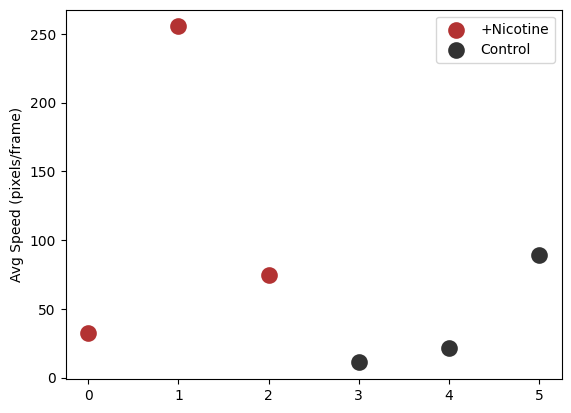

In [ ]:
plt.figure()
for ind,ele in enumerate(allStore):
  if ind == 0:
    plt.scatter(ind,np.nanmean(ele),color=(0.7,0.2,0.2),linewidth=2,s=100,label='+Nicotine')
  else:
    plt.scatter(ind,np.nanmean(ele),color=(0.7,0.2,0.2),linewidth=2,s=100)

for ind,ele in enumerate(allStore_control):
  if ind == 0:
    plt.scatter(ind+3,np.nanmean(ele),color=(0.2,0.2,0.2),linewidth=2,s=100,label='Control')
  else:
    plt.scatter(ind+3,np.nanmean(ele),color=(0.2,0.2,0.2),linewidth=2,s=100)
plt.legend()

plt.ylabel('Avg Speed (pixels/frame)')



# Arena Circle

In [ ]:
findBees = glob.glob('/content/biol470/final_project/*/assay1*')

allStore = {}
for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}

  allStore[bees.split('/')[-2]]['Circle'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([x_store[ind],y_store[ind]])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Circle'].append(speed)

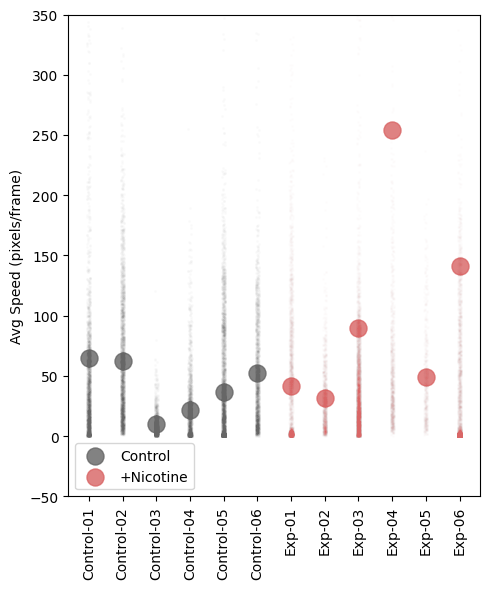

In [ ]:
plt.figure(figsize=(5,6))
nbee = {}
nsbee = {}
cbee = {}
csbee = {}

for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
    nbee[ele] = np.nanmean(allStore[ele]['Circle'])
    nsbee[ele] = np.nanstd(allStore[ele]['Circle'])/np.sqrt(len(allStore[ele]['Circle'][0]))
  else:
    cc1 = (0.2,0.2,0.2,0.5)
    cbee[ele] = np.nanmean(allStore[ele]['Circle'])
    csbee[ele] = np.nanstd(allStore[ele]['Circle'])/np.sqrt(len(allStore[ele]['Circle'][0]))



ind = 0

for ele in cbee:
  if ind == 0:
    plt.scatter(ind,np.nanmean(cbee[ele]),s=150,color=(0.4,0.4,0.4,0.82),label='Control')
  else:
    plt.scatter(ind,np.nanmean(cbee[ele]),s=150,color=(0.4,0.4,0.4,0.82))

  #plt.plot([ind,ind],[np.nanmean(cbee[ele])-csbee[ele],np.nanmean(cbee[ele])+csbee[ele]],color=(0.4,0.4,0.4,0.82))

  dd = ((np.random.rand(len(allStore[ele]['Circle'][0]))*0.1)+ind-0.05)
  plt.scatter(dd,allStore[ele]['Circle'][0],color=(0.4,0.4,0.4,0.02),s=1)
  ind+=1

for ele in nbee:
  if ind == 6:
    plt.scatter(ind,np.nanmean(nbee[ele]),s=150,color=(0.85,0.4,0.4,0.82),label='+Nicotine')
  else:
    plt.scatter(ind,np.nanmean(nbee[ele]),s=150,color=(0.85,0.4,0.4,0.82))

  dd = ((np.random.rand(len(allStore[ele]['Circle'][0]))*0.1)+ind-0.05)
  plt.scatter(dd,allStore[ele]['Circle'][0],color=(0.85,0.4,0.4,0.01),s=1)
  ind+=1

plt.legend()
plt.xticks(np.arange(0,12),['Control-01','Control-02','Control-03','Control-04','Control-05','Control-06',
                            'Exp-01','Exp-02','Exp-03','Exp-04','Exp-05','Exp-06'],rotation=90)
plt.ylabel('Avg Speed (pixels/frame)')
plt.ylim([-50,350])
plt.tight_layout()
plt.savefig('/content/circle_speed.png',dpi=300)

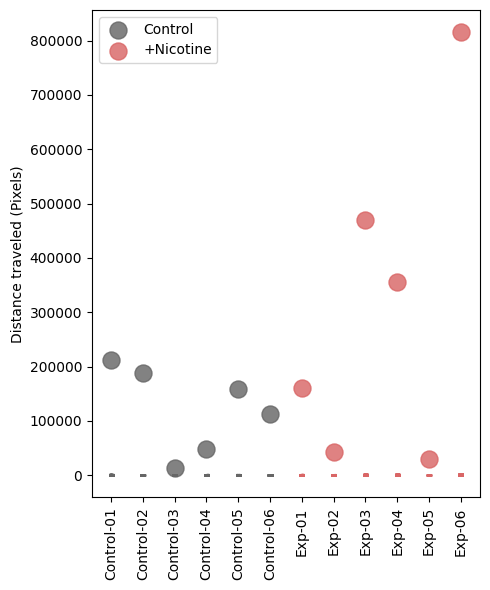

In [ ]:
plt.figure(figsize=(5,6))
nbee = {}
nsbee = {}
cbee = {}
csbee = {}

for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
    nbee[ele] = np.nansum(allStore[ele]['Circle'])
    nsbee[ele] = np.nanstd(allStore[ele]['Circle'])/np.sqrt(len(allStore[ele]['Circle'][0]))
  else:
    cc1 = (0.2,0.2,0.2,0.5)
    cbee[ele] = np.nansum(allStore[ele]['Circle'])
    csbee[ele] = np.nanstd(allStore[ele]['Circle'])/np.sqrt(len(allStore[ele]['Circle'][0]))



ind = 0

bbar = []
for ele in cbee:
  if ind == 0:
    plt.scatter(ind,np.nanmean(cbee[ele]),s=150,color=(0.4,0.4,0.4,0.82),label='Control')
  else:
    plt.scatter(ind,np.nanmean(cbee[ele]),s=150,color=(0.4,0.4,0.4,0.82))
  bbar.append(cbee[ele])
  #plt.plot([ind,ind],[np.nanmean(cbee[ele])-csbee[ele],np.nanmean(cbee[ele])+csbee[ele]],color=(0.4,0.4,0.4,0.82))

  dd = ((np.random.rand(len(allStore[ele]['Circle'][0]))*0.1)+ind-0.05)
  plt.scatter(dd,allStore[ele]['Circle'][0],color=(0.4,0.4,0.4,0.2),s=1)
  ind+=1

for ele in nbee:
  if ind == 6:
    plt.scatter(ind,np.nanmean(nbee[ele]),s=150,color=(0.85,0.4,0.4,0.82),label='+Nicotine')
  else:
    plt.scatter(ind,np.nanmean(nbee[ele]),s=150,color=(0.85,0.4,0.4,0.82))
  bbar.append(nbee[ele])
  dd = ((np.random.rand(len(allStore[ele]['Circle'][0]))*0.1)+ind-0.05)
  plt.scatter(dd,allStore[ele]['Circle'][0],color=(0.85,0.4,0.4,0.1),s=1)
  ind+=1

plt.legend()
plt.xticks(np.arange(0,12),['Control-01','Control-02','Control-03','Control-04','Control-05','Control-06',
                            'Exp-01','Exp-02','Exp-03','Exp-04','Exp-05','Exp-06'],rotation=90)
plt.ylabel('Distance traveled (Pixels)')
plt.tight_layout()
plt.savefig('/content/circle_dist.png',dpi=300)



/tmp/ipykernel_17187/2981826394.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


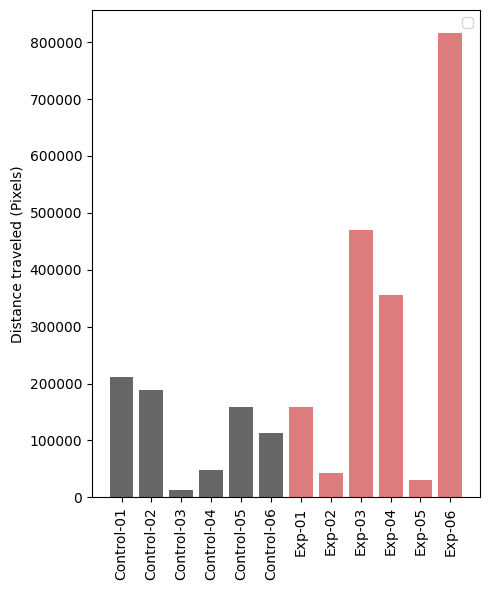

In [ ]:
plt.figure(figsize=(5,6))
plt.bar(np.arange(0,6),bbar[:6],color=(0.4,0.4,0.4))
plt.bar(np.arange(6,12),bbar[6:],color=(0.85,0.4,0.4,0.85))
plt.legend()
plt.xticks(np.arange(0,12),['Control-01','Control-02','Control-03','Control-04','Control-05','Control-06',
                            'Exp-01','Exp-02','Exp-03','Exp-04','Exp-05','Exp-06'],rotation=90)
plt.ylabel('Distance traveled (Pixels)')
plt.tight_layout()
a1 = plt.axis()
plt.savefig('/content/circle_dist_bar.png',dpi=300)

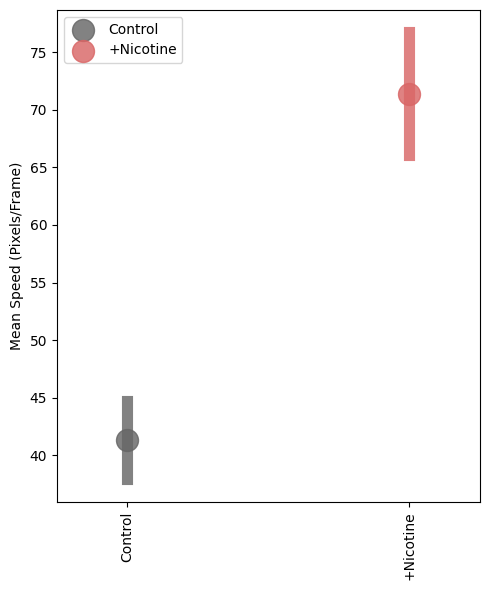

In [ ]:
plt.figure(figsize=(5,6))
ff = []

for ele in cbee:
  ff.append(cbee[ele])
control_mean = np.nanmean(ff)
control_sem = np.nanstd(ff)/len(ff)
ind = 0
plt.scatter(ind,control_mean,s=250,color=(0.4,0.4,0.4,0.82),label='Control')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.4,0.4,0.4,0.82),linewidth=8)

ind+=1
for ele in nbee:
  ff.append(nbee[ele])
control_mean = np.nanmean(ff)
control_sem = np.nanstd(ff)/len(ff)
plt.scatter(ind,control_mean,s=250,color=(0.85,0.4,0.4,0.82),label='+Nicotine')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.85,0.4,0.4,0.82),linewidth=8)
plt.legend()
plt.ylabel('Mean Speed (Pixels/Frame)')
plt.xticks(np.arange(0,2),['Control','+Nicotine'],rotation=90)
plt.xlim([-0.25,1.25])

plt.tight_layout()
plt.savefig('/content/mean_comp_speed.png',dpi=300)

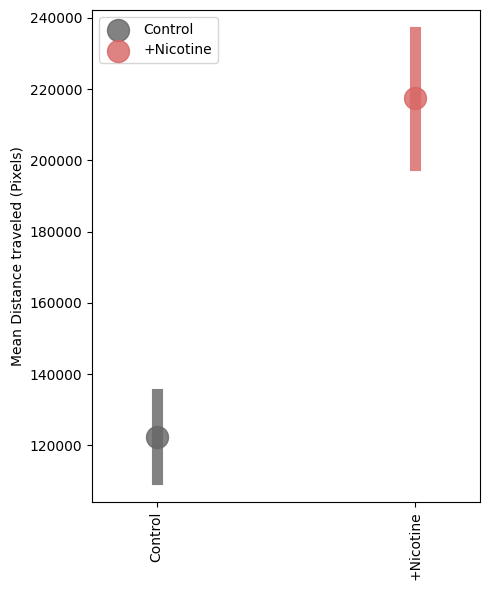

In [ ]:
plt.figure(figsize=(5,6))
ff = []

for ele in cbee:
  ff.append(cbee[ele])
control_mean = np.nanmean(ff)
control_sem = np.nanstd(ff)/len(ff)
ind = 0
plt.scatter(ind,control_mean,s=250,color=(0.4,0.4,0.4,0.82),label='Control')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.4,0.4,0.4,0.82),linewidth=8)

ind+=1
for ele in nbee:
  ff.append(nbee[ele])
control_mean = np.nanmean(ff)
control_sem = np.nanstd(ff)/len(ff)
plt.scatter(ind,control_mean,s=250,color=(0.85,0.4,0.4,0.82),label='+Nicotine')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.85,0.4,0.4,0.82),linewidth=8)
plt.legend()
plt.ylabel('Mean Distance traveled (Pixels)')
plt.xticks(np.arange(0,2),['Control','+Nicotine'],rotation=90)
plt.xlim([-0.25,1.25])

plt.tight_layout()

plt.tight_layout()
plt.savefig('/content/mean_comp_dist.png',dpi=300)

# Optomotor

In [ ]:
import math

In [ ]:
findBees = glob.glob('/content/biol470/final_project/*/assay2*fwd*')


for bees in findBees:

  allStore[bees.split('/')[-2]]['Opto_Fwd'] = []
  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []
  rad_store = []
  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  fx = []
  fy = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([2000,1500])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)
    fx.append(x_store[ind+1])
    fy.append(y_store[ind+1])
    #if temp < 500 and x_store[ind+1] > 1000:
    dx = 2000 - x_store[ind]
    dy = 1500 - y_store[ind]
    angle_rad = math.atan2(dy, dx)

    rad_store.append(angle_rad)

  allStore[bees.split('/')[-2]]['Opto_Fwd'].append(np.diff(rad_store))

In [ ]:
findBees = glob.glob('/content/biol470/final_project/*/assay2*rev*')


for bees in findBees:

  allStore[bees.split('/')[-2]]['Opto_Rev'] = []
  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []
  rad_store = []
  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  fx = []
  fy = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([2000,1500])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)
    fx.append(x_store[ind+1])
    fy.append(y_store[ind+1])
    #if temp < 500 and x_store[ind+1] > 1000:
    dx = 2000 - x_store[ind]
    dy = 1500 - y_store[ind]
    angle_rad = math.atan2(dy, dx)

    rad_store.append(angle_rad)

  allStore[bees.split('/')[-2]]['Opto_Rev'].append(np.diff(rad_store))

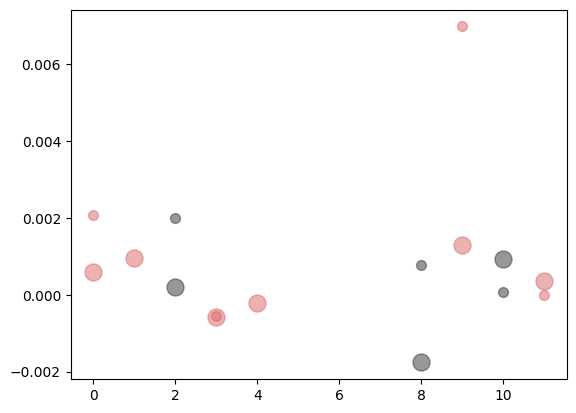

In [ ]:
plt.figure()
for ind,ele in enumerate(allStore.keys()):
  if 'Opto' not in allStore[ele]:continue
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  if 'Opto_Fwd' in allStore[ele]:
    plt.scatter(ind,np.nanmean(allStore[ele]['Opto_Fwd']),s=150,color=cc1)
  if 'Opto_Rev' in allStore[ele]:
    plt.scatter(ind,np.nanmean(allStore[ele]['Opto_Rev']),s=50,color=cc1)

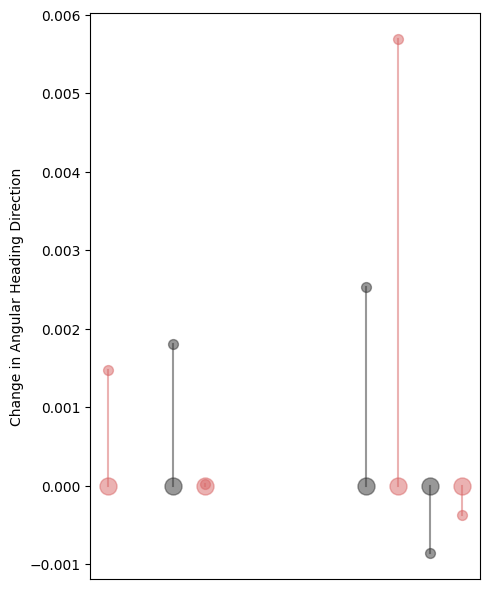

In [ ]:
#plt.figure()
plt.figure(figsize=(5,6))
crot = []
nrot = []
for ind,ele in enumerate(allStore.keys()):
  if 'Opto' not in allStore[ele]:continue
  if 'Opto_Fwd' not in allStore[ele] or 'Opto_Rev' not in allStore[ele]:continue
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
    crot.append(np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd']))
  else:
    cc1 = (0.2,0.2,0.2,0.5)
    nrot.append(np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd']))

  if 'Opto_Fwd' in allStore[ele] and 'Opto_Rev' in allStore[ele]:


    plt.scatter(ind,np.nanmean(allStore[ele]['Opto_Fwd'])-np.nanmean(allStore[ele]['Opto_Fwd']),s=150,color=cc1)
    plt.scatter(ind,np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd']),s=50,color=cc1)
    plt.plot([ind,ind],[np.nanmean(allStore[ele]['Opto_Fwd'])-np.nanmean(allStore[ele]['Opto_Fwd']),np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd'])],color=cc1)


plt.ylabel('Change in Angular Heading Direction')
plt.xticks([])
plt.tight_layout()
plt.savefig('/content/change_opto_ang.png',dpi=300)

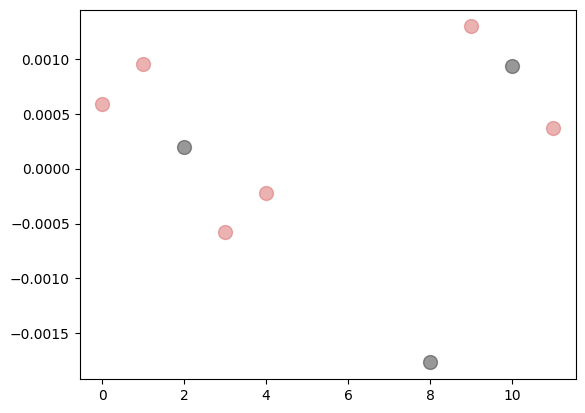

In [ ]:
plt.figure()
for ind,ele in enumerate(allStore.keys()):
  if 'Opto' not in allStore[ele]:continue
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  plt.scatter(ind,np.nanmean(allStore[ele]['Opto']),s=100,color=cc1)

In [ ]:
plt.scatter(ind,np.nanmean(allStore[ele]['Opto']),s=100,color=cc1)

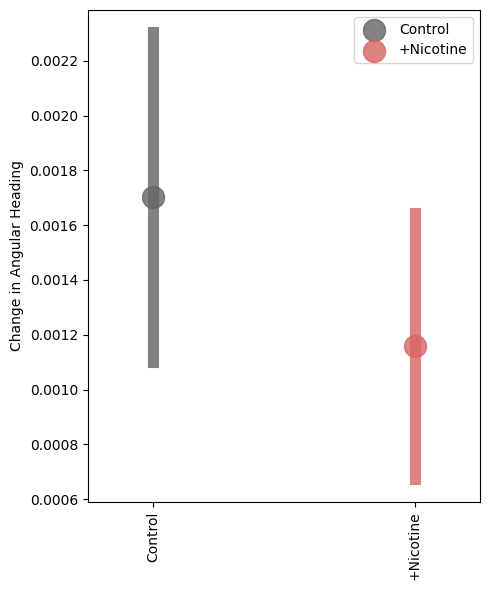

In [ ]:
plt.figure(figsize=(5,6))
ff = []


control_mean = np.nanmean(crot)
control_sem = np.nanstd(crot)/len(crot)
ind = 0
plt.scatter(ind,control_mean,s=250,color=(0.4,0.4,0.4,0.82),label='Control')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.4,0.4,0.4,0.82),linewidth=8)

ind+=1
for ele in nbee:
  ff.append(nbee[ele])
control_mean = np.nanmean(nrot)
control_sem = np.nanstd(nrot)/len(nrot)
plt.scatter(ind,control_mean,s=250,color=(0.85,0.4,0.4,0.82),label='+Nicotine')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.85,0.4,0.4,0.82),linewidth=8)
plt.legend()
plt.ylabel('Change in Angular Heading')
plt.xticks(np.arange(0,2),['Control','+Nicotine'],rotation=90)
plt.xlim([-0.25,1.25])

plt.tight_layout()

plt.tight_layout()
plt.savefig('/content/change_opto_dist.png',dpi=300)

# Shaded Preference

In [ ]:
findBees = glob.glob('/content/biol470/final_project/*/assay3*')

for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}

  allStore[bees.split('/')[-2]]['Shade'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([x_store[ind],y_store[ind]])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Shade'].append(speed)

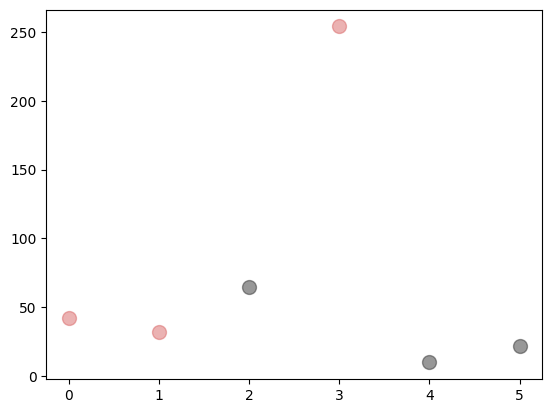

In [ ]:
plt.figure()
nbee = {}
cbee = {}

for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
    nbee[ele] = np.nanmean(allStore[ele]['Shade'])
  else:
    cc1 = (0.2,0.2,0.2,0.5)
    cbee[ele] = np.nanmean(allStore[ele]['Shade'])



  plt.scatter(ind,np.nanmean(allStore[ele]['Shade']),s=100,color=cc1)

# Air Responses

In [ ]:
findBees = glob.glob('/content/biol470/final_project/*/assay4*')

for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}
  allStore[bees.split('/')[-2]]['Air'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  #plt.figure()
  #plt.plot(x_store,y_store)
  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([3200,1500])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Air'].append(speed)


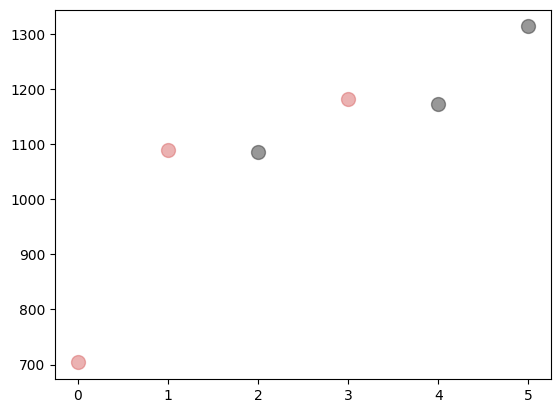

In [ ]:
plt.figure()
for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  plt.scatter(ind,np.nanmean(allStore[ele]['Air']),s=100,color=cc1)

# Citronella Responses

In [ ]:
findBees = glob.glob('/content/biol470/final_project/*/assay5*')


for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}
  allStore[bees.split('/')[-2]]['Cit'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([4000,2000])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Cit'].append(speed)


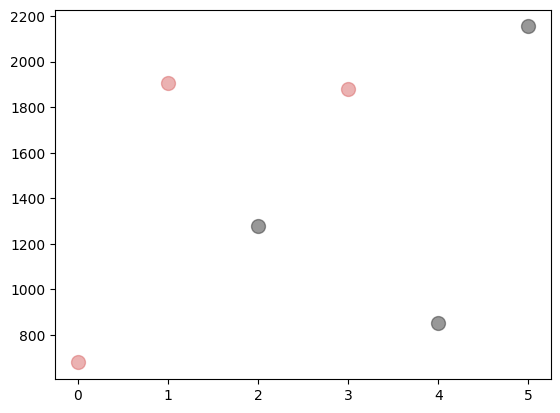

In [ ]:
plt.figure()
for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  plt.scatter(ind,np.nanmean(allStore[ele]['Cit']),s=100,color=cc1)

# Linalool Responses

In [ ]:
findBees = glob.glob('/content/biol470/final_project/*/assay6*')

for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}
  allStore[bees.split('/')[-2]]['Lin'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([4000,2000])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Lin'].append(speed)


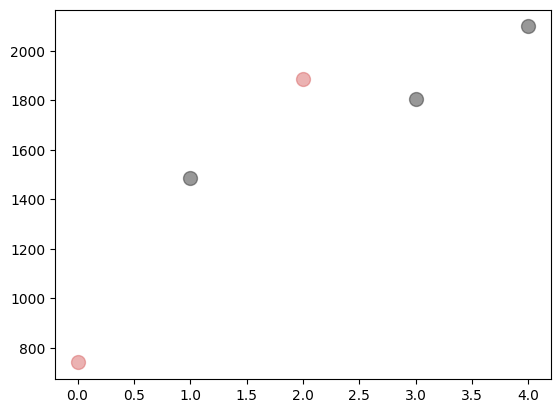

In [ ]:
plt.figure()
for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  plt.scatter(ind,np.nanmean(allStore[ele]['Lin']),s=100,color=cc1)

In [ ]:
!unzip /content/frames.zip

In [ ]:
import cv2 as cv

In [ ]:
in1 = cv.imread('/content/frames/bee_0408_2/final_bee_0408_2_air_cam1_2026-04-08_17-10-27.jpg')

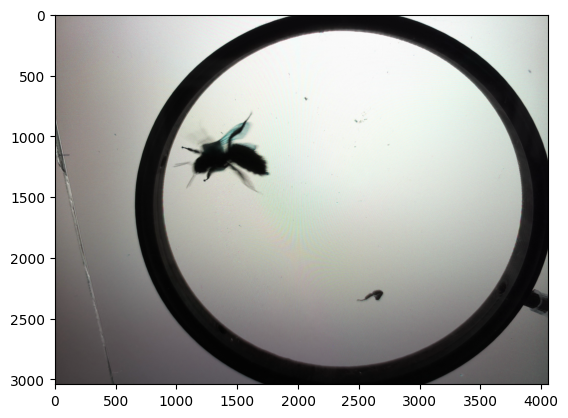

In [ ]:
plt.imshow(in1)

In [ ]:
in1 = cv.imread('/content/frames/bee_0408_3/final_bee_test_cit_cam1_2026-04-08_17-46-11.jpg')

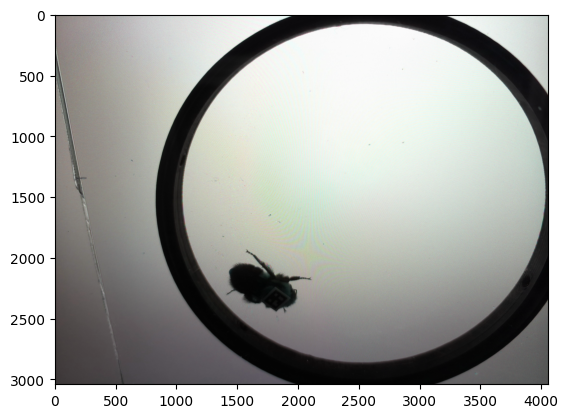

In [ ]:
plt.imshow(in1)

# Matrix

In [ ]:
getAll = {}
for ele in allStore:
  for ee in allStore[ele]:
    if ee not in getAll:
      getAll[ee] = []


In [ ]:
getAll.keys()

dict_keys(['Circle', 'Opto_Fwd', 'Shade', 'Air', 'Cit', 'Lin', 'Opto_Rev'])

In [ ]:
allStore['nicotine_bee_2'].keys()

dict_keys(['Circle', 'Opto_Fwd', 'Shade', 'Air', 'Cit', 'Lin'])

In [ ]:
getAll = ['Circle', 'Opto_Fwd', 'Opto_Rev','Shade', 'Air', 'Cit', 'Lin']

In [ ]:
nmat = []
cmat = []

nMAT = {}
cMAT = {}
aMAT = {}

for ele in allStore:
  temp = []
  for ee in getAll:
    if ee not in nMAT:
      nMAT[ee] = []
      cMAT[ee] = []
      aMAT[ee] = []

    if ee not in allStore[ele]:
      temp.append(np.nan)
      if 'nic' in ele:
        nMAT[ee].append(np.nan)
      else:
        cMAT[ee].append(np.nan)

      aMAT[ee].append(np.nan)

    else:
      temp.append(np.nanmean(allStore[ele][ee]))

      if 'nic' in ele:
        nMAT[ee].append(np.nanmean(allStore[ele][ee]))
      else:
        cMAT[ee].append(np.nanmean(allStore[ele][ee]))

      aMAT[ee].append(np.nanmean(allStore[ele][ee]))

  if 'nic' in ele:

    nmat.append(temp)
  else:
    cmat.append(temp)


In [ ]:
import pandas as pd
df = pd.DataFrame(aMAT)
matrix = df.corr(numeric_only=True)

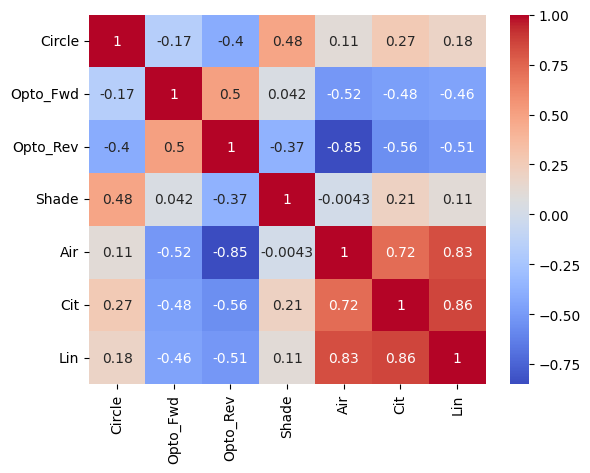

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.show()


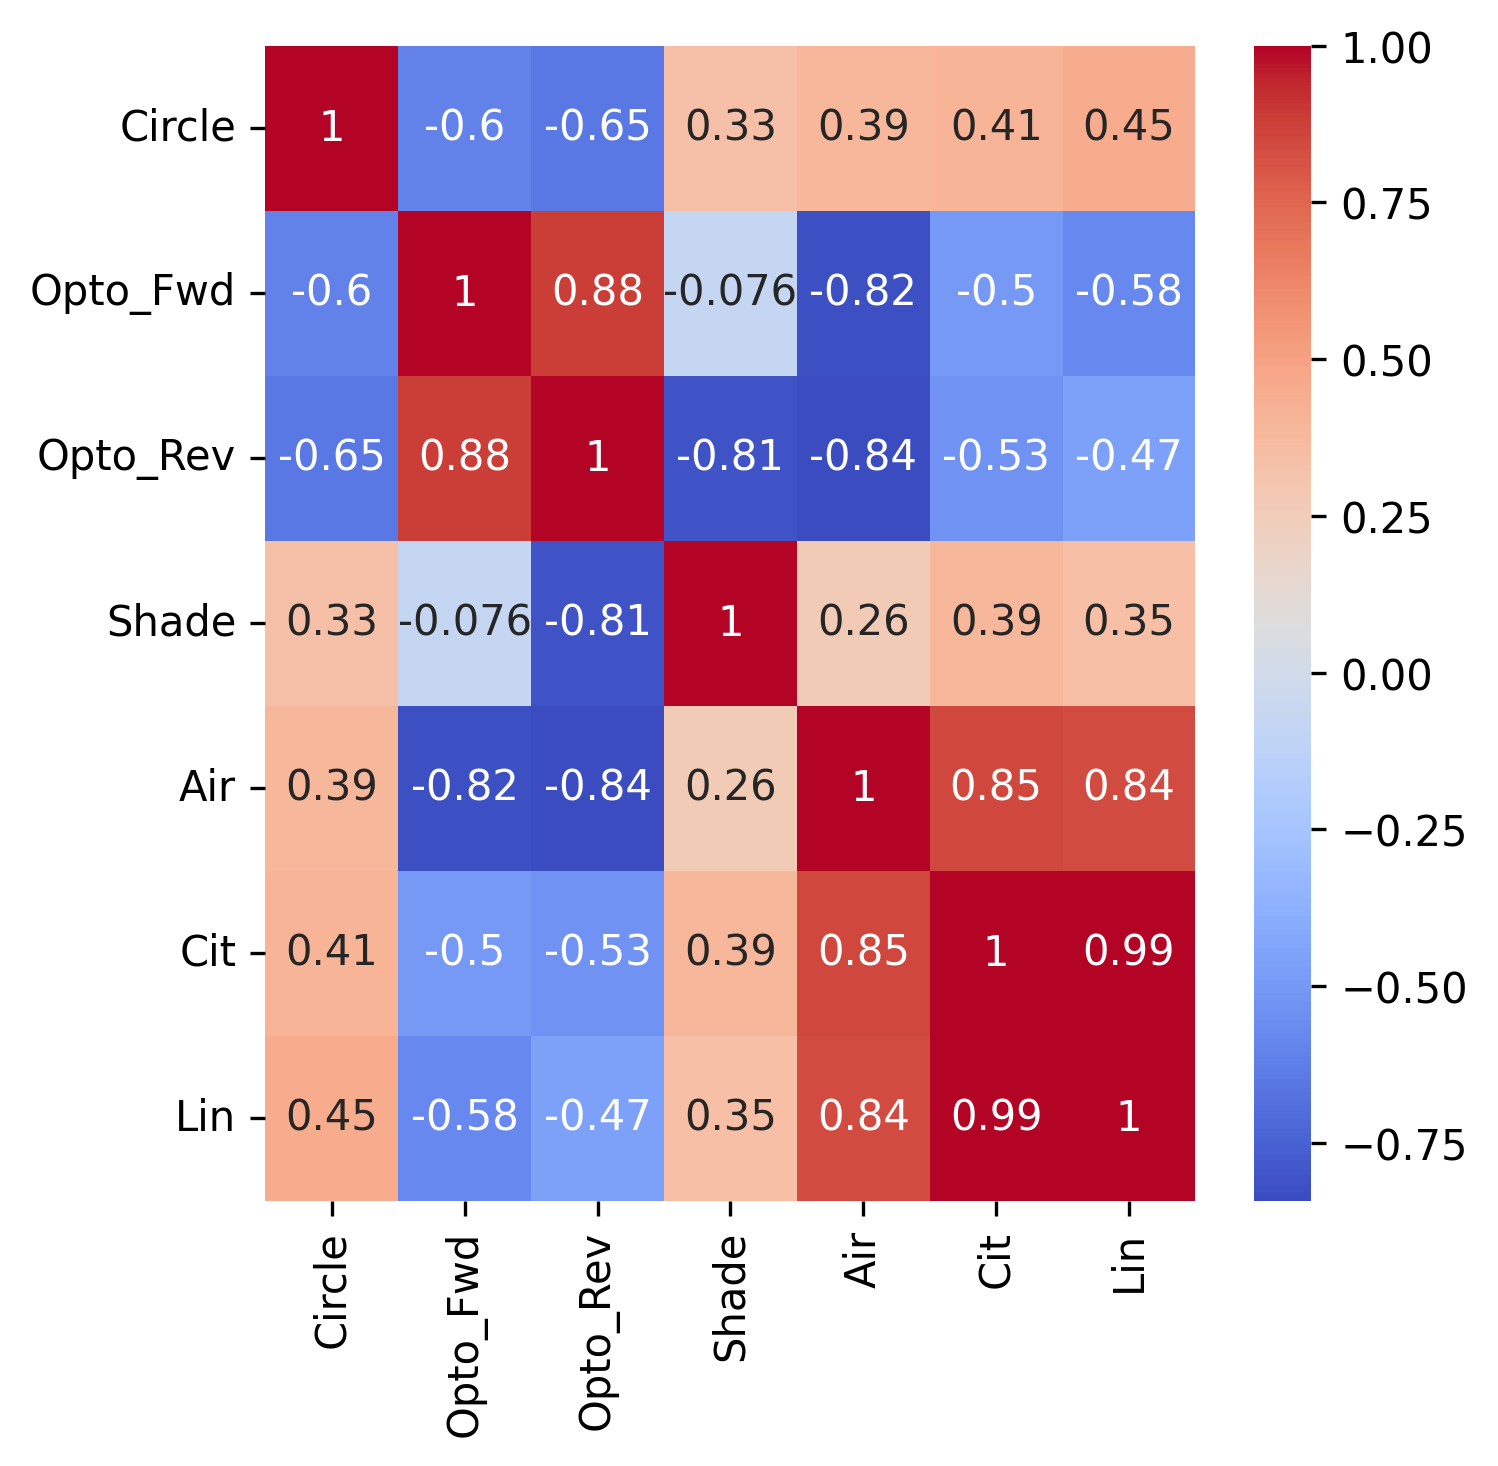

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
df = pd.DataFrame(nMAT)
matrix = df.corr(numeric_only=True)
plt.figure(figsize=(5,5),dpi=300)

import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.show()
plt.savefig('/content/nmat.png',dpi=300)

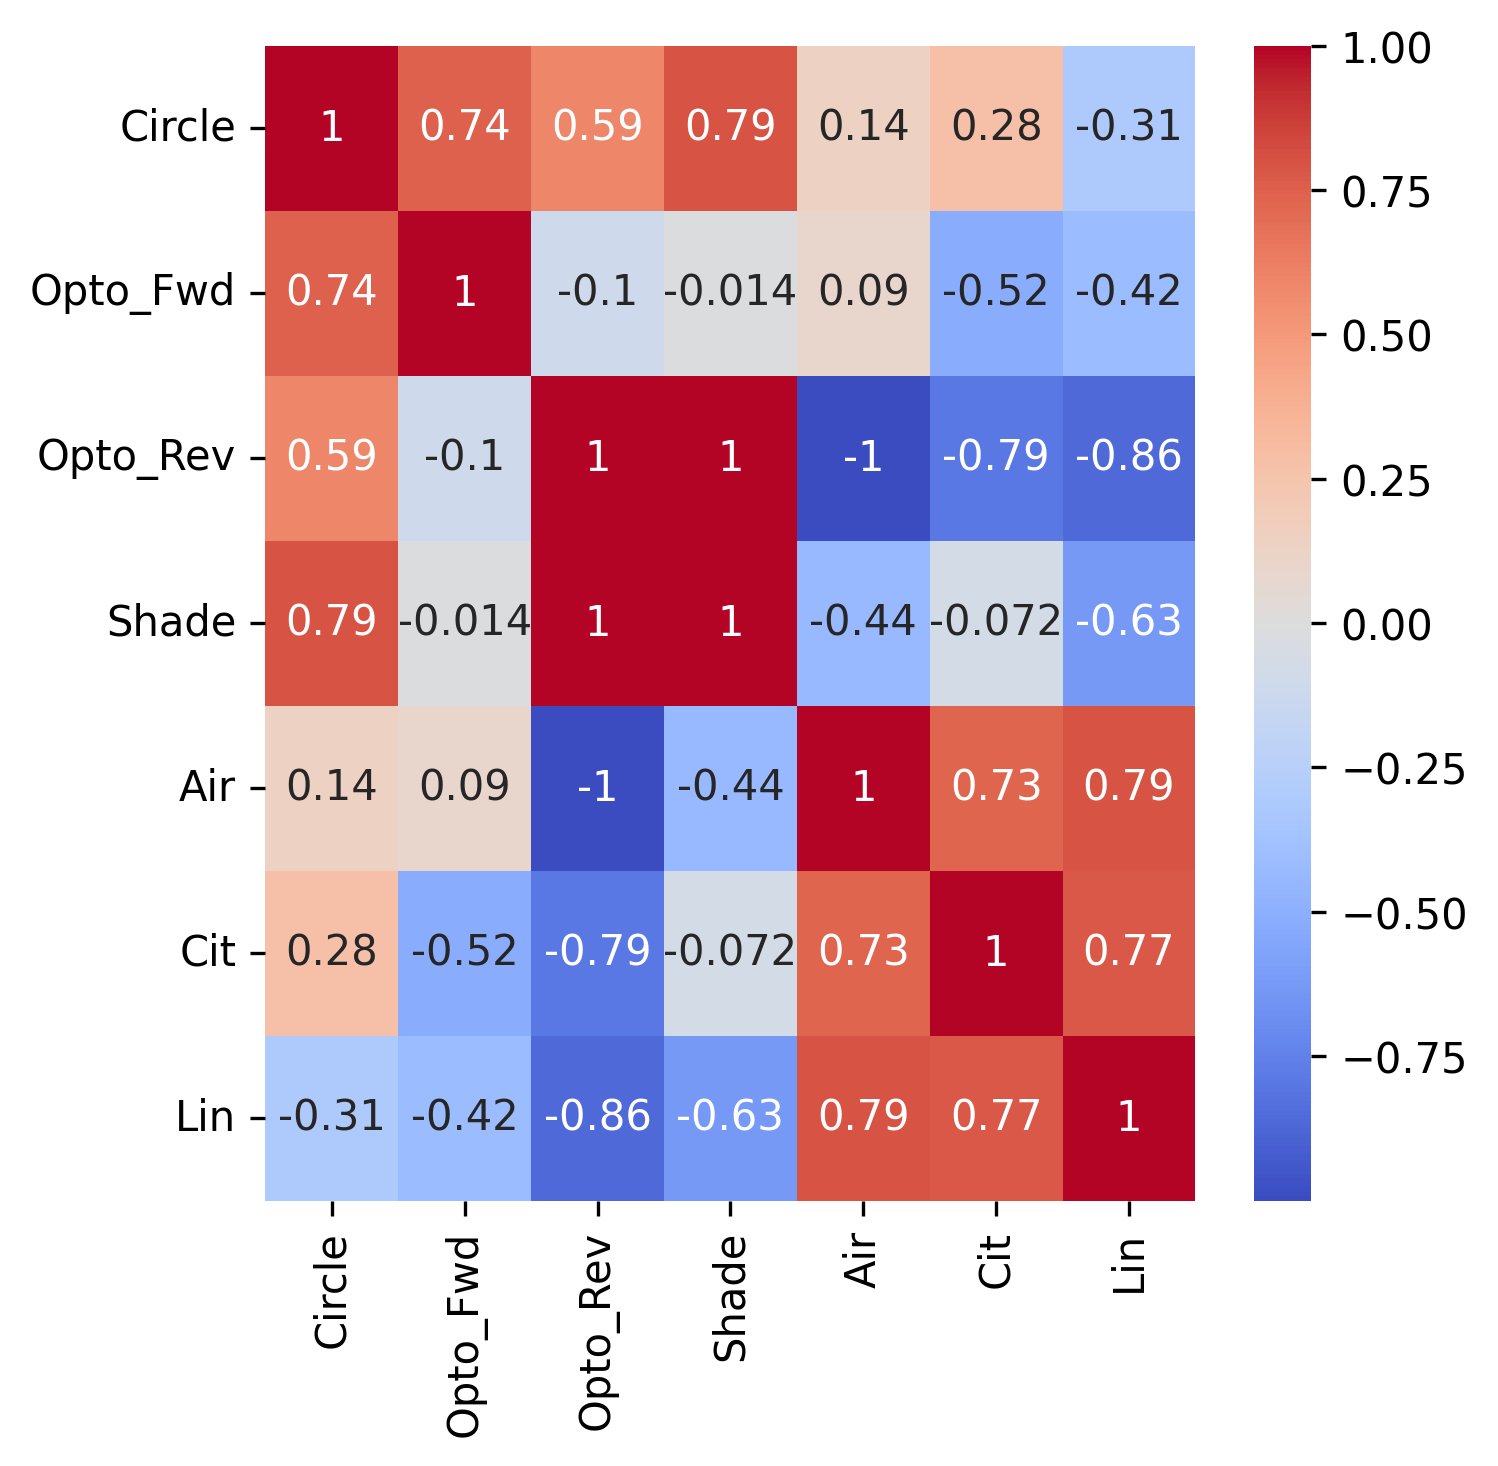

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
df = pd.DataFrame(cMAT)
matrix = df.corr(numeric_only=True)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5),dpi=300)
sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.show()
plt.savefig('/content/cmat.pdf',dpi=300)

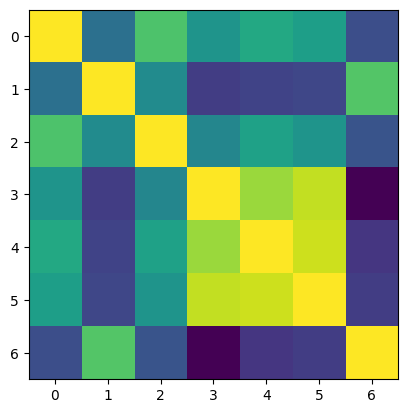

In [ ]:
plt.imshow(matrix)

In [ ]:
mm.shape

(12, 7)

In [ ]:
mm = np.zeros((12,7))

for ind,ele in enumerate(cmat):
  mm[ind,:] = ele

ind+=1
for ele in nmat:
  mm[ind,:] = ele
  ind+=1


for ele in range(mm.shape[1]):
  temp = mm[:,ele]
  t1 = (temp-np.nanmean(temp))/np.nanstd(temp)
  mm[:,ele] = t1


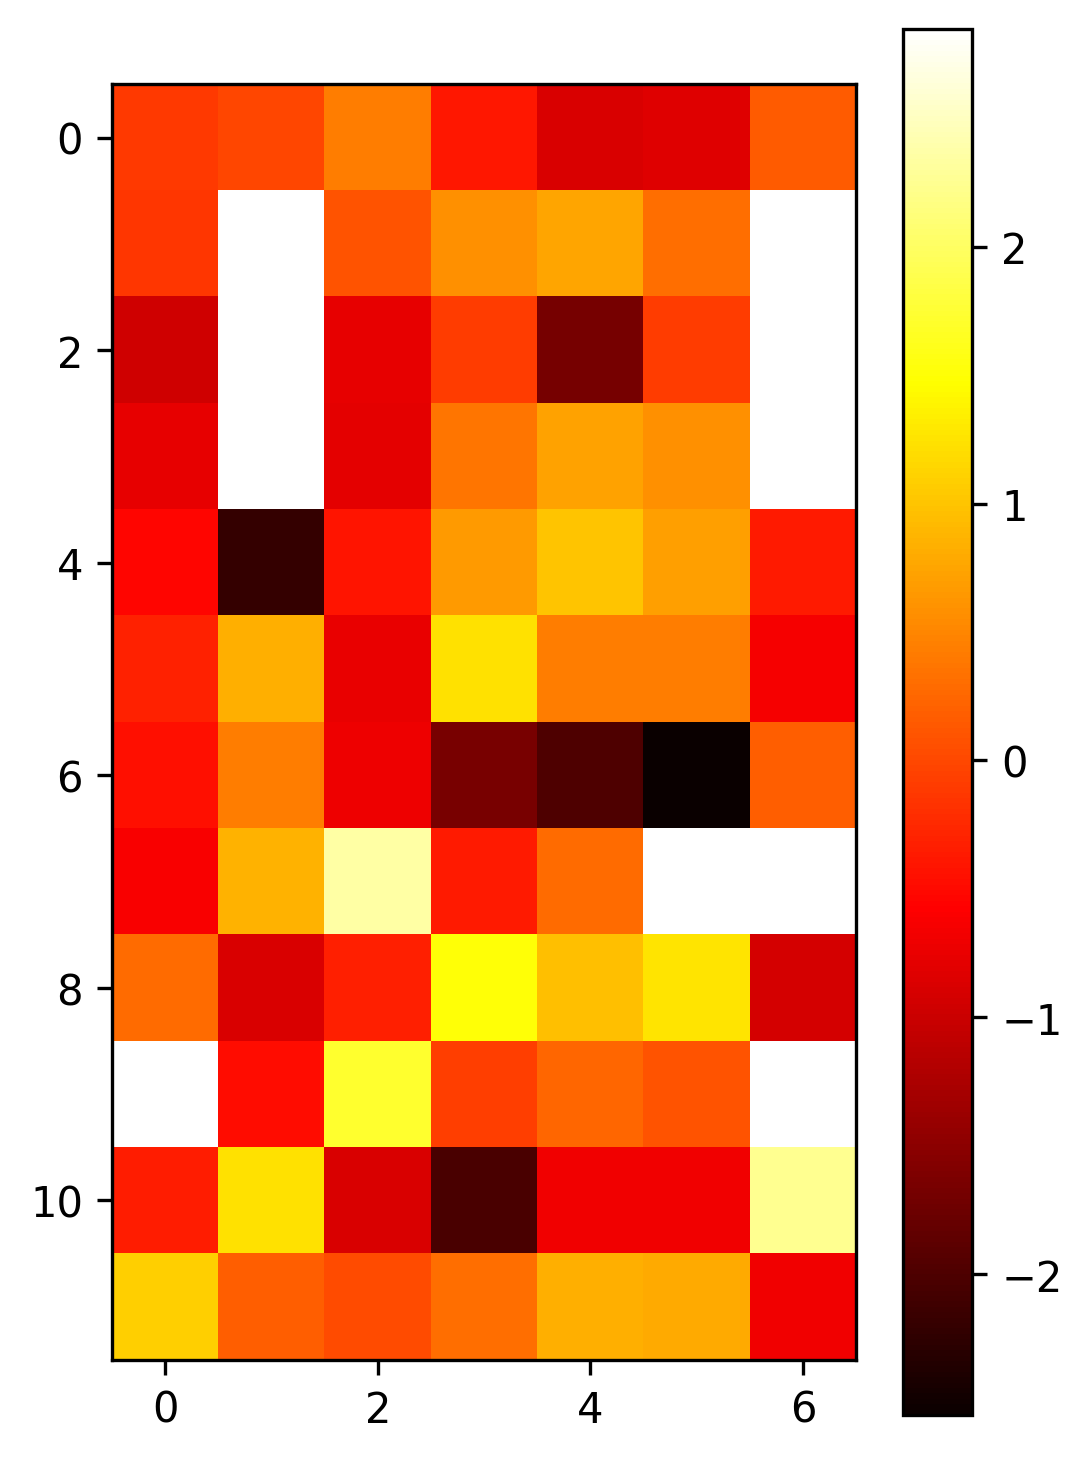

In [ ]:

plt.figure(figsize=(4,6),dpi=300)
plt.imshow(mm,cmap=plt.cm.hot)
plt.colorbar()
plt.grid(False)
plt.savefig('/content/matrix.png',dpi=200)

In [ ]:
len(cmat[0])

7

In [ ]:
len(nmat)

6

42

In [ ]:
np.nanmean(allStore['nicotine_bee_2']['Circle'])
np.nanmean(allStore['nicotine_bee_2']['Opto_Fwd'])
np.nanmean(allStore['nicotine_bee_2']['Opto_Rev'])
np.nanmean(allStore['nicotine_bee_2']['Shade'])
np.nanmean(allStore['nicotine_bee_2']['Air'])
np.nanmean(allStore['nicotine_bee_2']['Cit'])
np.nanmean(allStore['nicotine_bee_2']['Lin'])

np.float64(254.0289305145478)

In [ ]:
'Opto_Fwd'

In [ ]:
#plt.figure()
crot = []
nrot = []
for ind,ele in enumerate(allStore.keys()):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
    crot.append(np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd']))
  else:
    cc1 = (0.2,0.2,0.2,0.5)
    nrot.append(np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd']))

  if 'Opto_Fwd' in allStore[ele] and 'Opto_Rev' in allStore[ele]:


    plt.scatter(ind,np.nanmean(allStore[ele]['Opto_Fwd'])-np.nanmean(allStore[ele]['Opto_Fwd']),s=150,color=cc1)
    plt.scatter(ind,np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd']),s=50,color=cc1)
    plt.plot([ind,ind],[np.nanmean(allStore[ele]['Opto_Fwd'])-np.nanmean(allStore[ele]['Opto_Fwd']),np.nanmean(allStore[ele]['Opto_Rev'])-np.nanmean(allStore[ele]['Opto_Fwd'])],color=cc1)


plt.ylabel('Change in Angular Heading Direction')
plt.xticks([])
plt.tight_layout()
plt.savefig('/content/change_opto_ang.png',dpi=300)

# Learning data

In [6]:
import pandas as pd

In [77]:
data_in = pd.read_csv('/content/biol470/final_project/bee_0408_1_fwd/learninf_cam1_2026-04-08_16-15-57_key.csv')

In [51]:
t = data_in.iat[0,3]
t

np.float64(2256.5)

In [98]:
def get_single_signal(data_in):
  original_centroid_x = 1265.0
  original_centroid_y = 2256.5
  lim = 350
  data_len = len(data_in)
  data_out = data_in.copy()
  for i in range(0,data_len-1):
    if data_in.iat[i,2] >= original_centroid_x - lim and data_in.iat[i,2] <= original_centroid_x + lim and data_in.iat[i,3] >= original_centroid_y - lim and data_in.iat[i,3] <= original_centroid_y + lim:
      original_centroid_x = data_in.iat[i,2]
      original_centroid_y = data_in.iat[i,3]
      i += 1
    else:
      data_out = data_out[data_out['Unnamed: 0'] != i]
      i += 1
  return data_out


In [73]:
print(len(data_in))

2459


In [99]:
print(len(data_in))
data_see = get_single_signal(data_in)

2459


In [100]:
data_see

,Unnamed: 0,filepath,x_centroid,y_centroid,x_min,y_min,x_max,y_max,detection_confidence
0,0,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1265.0,2256.5,972,2017,1558,2496,0.785697
2,2,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1257.5,2255.0,969,2018,1546,2492,0.783008
4,4,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1252.0,2257.0,972,2019,1532,2495,0.789962
6,6,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1260.0,2255.0,971,2013,1549,2497,0.790964
8,8,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1246.5,2257.0,968,2024,1525,2490,0.787390
...,...,...,...,...,...,...,...,...,...
2345,2345,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1263.5,1840.0,937,1486,1590,2194,0.773607
2347,2347,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1143.5,1738.0,896,1391,1391,2085,0.787233
2350,2350,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1157.5,1646.5,910,1310,1405,1983,0.795153
2352,2352,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1158.0,1753.5,902,1518,1414,1989,0.739882


In [76]:
data_in

,Unnamed: 0,filepath,x_centroid,y_centroid,x_min,y_min,x_max,y_max,detection_confidence
0,0,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1265.0,2256.5,972,2017,1558,2496,0.785697
1,1,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,2459.0,2752.0,2190,2464,2728,3040,0.780872
2,2,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1257.5,2255.0,969,2018,1546,2492,0.783008
3,3,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,2460.0,2752.5,2191,2465,2729,3040,0.751665
4,4,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1252.0,2257.0,972,2019,1532,2495,0.789962
...,...,...,...,...,...,...,...,...,...
2454,2454,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,2458.5,2751.0,2191,2462,2726,3040,0.782477
2455,2455,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,2458.5,2751.0,2192,2462,2725,3040,0.788866
2456,2456,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,1851.0,500.5,1455,229,2247,772,0.778581
2457,2457,/Volumes/SmithL0/2026/BIOL470/Final/Learning_R...,2457.5,2751.5,2191,2464,2724,3039,0.796552


Text(0.5, 0, 'time')

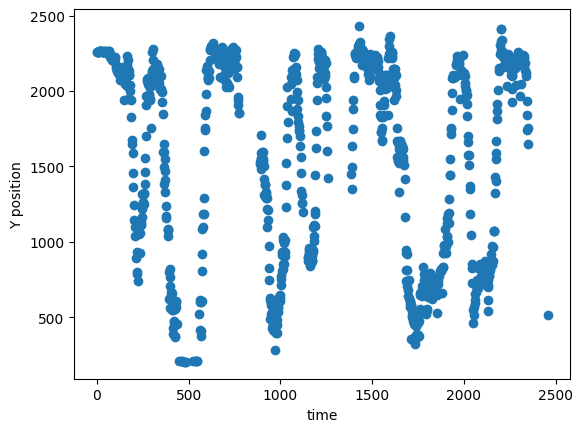

In [101]:
plt.scatter(data_see['Unnamed: 0'], data_see['y_centroid'])
plt.ylabel("Y position")
plt.xlabel("time")

(array([ 169.,  105.,   71.,   83.,  158.,  458., 1075.,  323.,   13.,
           4.]),
 array([0.50016785, 0.54286848, 0.58556912, 0.62826976, 0.67097039,
        0.71367103, 0.75637166, 0.79907229, 0.84177293, 0.88447356,
        0.9271742 ]),
 <BarContainer object of 10 artists>)

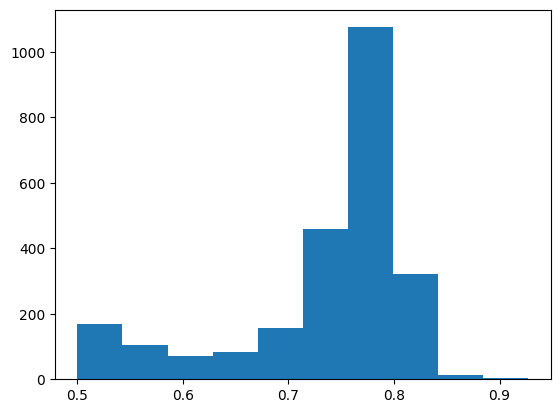

In [37]:
conf = data_in["detection_confidence"].values
plt.hist(conf)

use size to approximate "validity box"

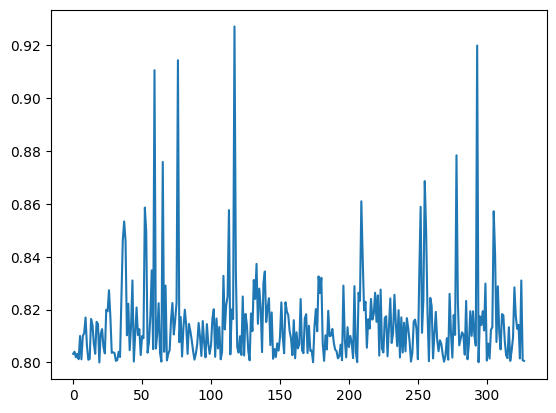

In [38]:
threshold = .8

def cut_bounds(data_in, thres_conf, thres_x_max, thres_x_min, thres_y_max, thres_y_min):
  data_in = data_in[data_in["detection_confidence"] >= thres_conf]
  data_in = data_in[data_in["x_centroid"] <= thres_x_max]
  data_in = data_in[data_in["x_centroid"] >= thres_x_min]
  data_in = data_in[data_in["y_centroid"] <= thres_y_max]
  data_in = data_in[data_in["y_centroid"] >= thres_y_min]
  return data_in

g = data_in[data_in["detection_confidence"] >= threshold]
index = np.array(data_in["detection_confidence"].values)
index_cut = np.array(g["detection_confidence"].values)
plt.plot(index_cut)

Text(0.5, 0, 'time')

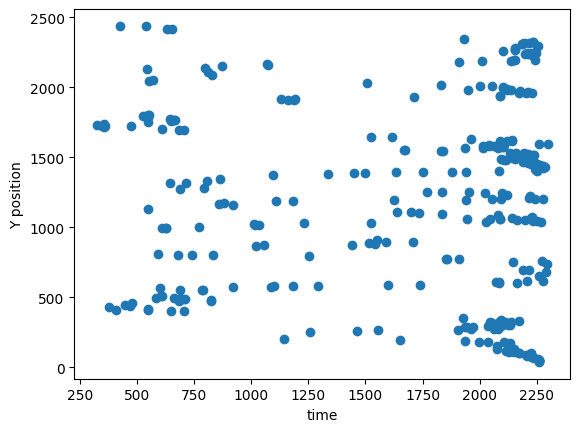

In [39]:
good_data = cut_bounds(data_in, .8, 3000, 0, 2500, 100)
x_dim = data_in['x_centroid']
y_dim = data_in['y_centroid']
plt.Figure()
plt.scatter(good_data['y_centroid'], good_data['Unnamed: 0'])
plt.ylabel("Y position")
plt.xlabel("time")

Centroid min/max centroid diff between frames

Text(0.5, 0, 'time')

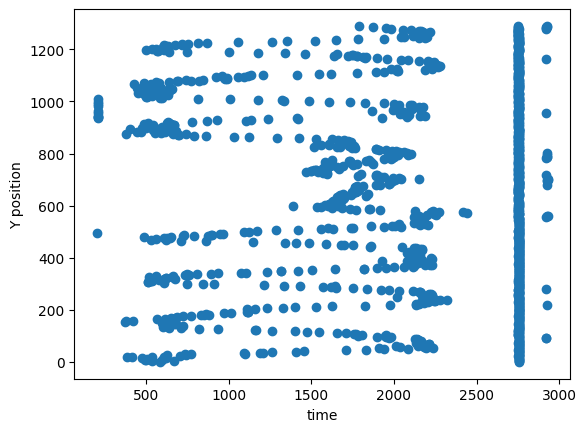

In [33]:
plt.scatter(data_in['y_centroid'], data_in['Unnamed: 0'])
plt.ylabel("Y position")
plt.xlabel("time")